#### ***00 — Exploratory Data Analysis***

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

import warnings
warnings.filterwarnings('ignore')

# Plot defaults
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

## Load the dataset

We pulled the raw CSV from the City of Boulder open-data portal and dropped it in `../data/`. The file has a UTF-8 BOM, so we read it with `encoding='utf-8-sig'`.

In [3]:
# Path to the raw CSV (downloaded from the Boulder Open Data portal)
CSV_PATH = '../data/Electric_Vehicle_Charging_Station_Data.csv'

# encoding='utf-8-sig' strips the BOM at the start of the file
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

print(f'Shape: {df.shape}')
df.head()

Shape: (148136, 17)


,ObjectId2,Station_Name,Address,City,State_Province,Zip_Postal_Code,Start_Date___Time,Start_Time_Zone,End_Date___Time,End_Time_Zone,Total_Duration__hh_mm_ss_,Charging_Time__hh_mm_ss_,Energy__kWh_,GHG_Savings__kg_,Gasoline_Savings__gallons_,Port_Type,ObjectID
0,1,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/1/2018 17:49,MDT,1/1/2018 19:52,MDT,2:03:02,2:02:44,6.504,2.732,0.816,Level 2,0
1,2,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 8:52,MDT,1/2/2018 9:16,MDT,0:24:34,0:24:19,2.481,1.042,0.311,Level 2,1
2,3,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 21:11,MDT,1/3/2018 6:23,MDT,9:12:21,3:40:52,15.046,6.319,1.888,Level 2,2
3,4,BOULDER / ALPINE ST1,1275 Alpine Ave,Boulder,Colorado,80304,1/3/2018 9:19,MDT,1/3/2018 11:14,MDT,1:54:51,1:54:29,6.947,2.918,0.872,Level 2,3
4,5,BOULDER / BASELINE ST1,900 Baseline Rd,Boulder,Colorado,80302,1/3/2018 14:13,MDT,1/3/2018 14:30,MDT,0:16:58,0:16:44,1.800,0.756,0.226,Level 2,4


## Schema and missing values

In [4]:
# Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148136 entries, 0 to 148135
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ObjectId2                   148136 non-null  int64  
 1   Station_Name                148136 non-null  str    
 2   Address                     148136 non-null  str    
 3   City                        148136 non-null  str    
 4   State_Province              148136 non-null  str    
 5   Zip_Postal_Code             148136 non-null  int64  
 6   Start_Date___Time           148136 non-null  str    
 7   Start_Time_Zone             148136 non-null  str    
 8   End_Date___Time             148132 non-null  str    
 9   End_Time_Zone               148136 non-null  str    
 10  Total_Duration__hh_mm_ss_   148136 non-null  str    
 11  Charging_Time__hh_mm_ss_    148136 non-null  str    
 12  Energy__kWh_                148136 non-null  float64
 13  GHG_Savings__kg_         

In [5]:
# Missing values per column (sorted)
df.isna().sum().sort_values(ascending=False)

End_Date___Time               4
ObjectId2                     0
Station_Name                  0
City                          0
Address                       0
State_Province                0
Zip_Postal_Code               0
Start_Date___Time             0
Start_Time_Zone               0
End_Time_Zone                 0
Total_Duration__hh_mm_ss_     0
Charging_Time__hh_mm_ss_      0
Energy__kWh_                  0
GHG_Savings__kg_              0
Gasoline_Savings__gallons_    0
Port_Type                     0
ObjectID                      0
dtype: int64

## Parse timestamps

The session start and end times come as strings. We parsed them to `datetime` and kept the session date as the unit of daily aggregation.

In [6]:
# Parse session start and end timestamps
df['Start_Date___Time'] = pd.to_datetime(df['Start_Date___Time'], errors='coerce')
df['End_Date___Time']   = pd.to_datetime(df['End_Date___Time'],   errors='coerce')

# Date of the charging session (used later for daily aggregation)
df['date'] = df['Start_Date___Time'].dt.normalize()

print('Date range:', df['date'].min().date(), '->', df['date'].max().date())
print('Total sessions:', len(df))

Date range: 2018-01-01 -> 2023-11-30
Total sessions: 148136


## Station-level overview

In [7]:
# Number of unique stations in the dataset
print('Unique stations:', df['Station_Name'].nunique())

# Top 10 stations by session count
top_stations = df['Station_Name'].value_counts().head(10)
top_stations

Unique stations: 50


Station_Name
BOULDER / N BOULDER REC 1       16278
BOULDER / BASELINE ST1          13458
BOULDER / CARPENTER PARK1       11823
BOULDER / CARPENTER PARK2        9164
BOULDER / EAST REC               9056
COMM VITALITY / 1100WALNUT1      8302
COMM VITALITY / 1104 SPRUCE1     7802
BOULDER / REC CENTER ST2         7617
COMM VITALITY / 1000WALNUT1      6738
BOULDER / ATRIUM ST1             6671
Name: count, dtype: int64

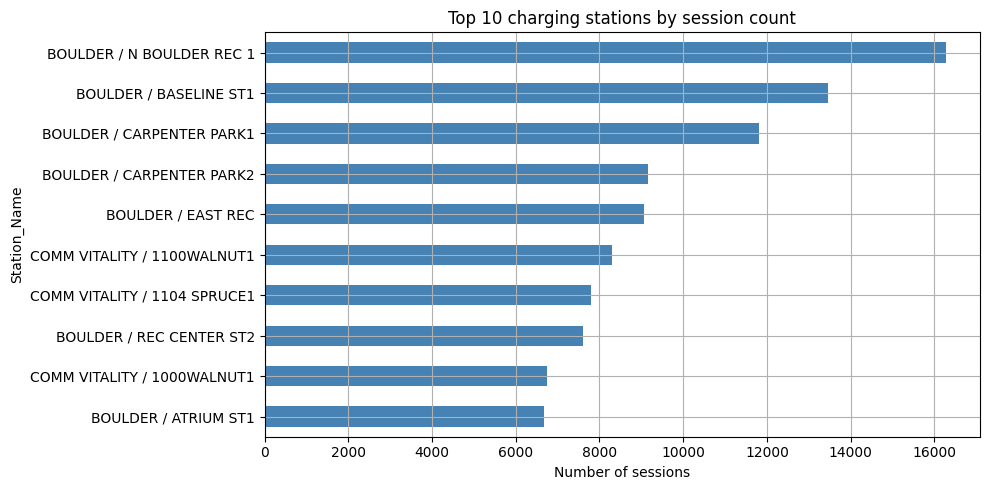

In [8]:
# Plot the top-10 stations by number of sessions
fig, ax = plt.subplots(figsize=(10, 5))
top_stations.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of sessions')
ax.set_title('Top 10 charging stations by session count')
plt.tight_layout()
plt.show()

## Target station selection

We picked the **highest-volume** station to maximise daily signal density. Forecasting a single, busy station gave us a cleaner univariate series than aggregating heterogeneous sites with very different usage patterns.

In [9]:
# Pick the station with the largest number of recorded sessions
TARGET_STATION = top_stations.index[0]
print('Target station:', TARGET_STATION)

# Subset for the target station only
df_station = df[df['Station_Name'] == TARGET_STATION].copy()
print('Sessions at target station:', len(df_station))

Target station: BOULDER / N BOULDER REC 1
Sessions at target station: 16278


## Session-level distributions

In [10]:
# Summary statistics for energy and GHG savings at the target station
df_station[['Energy__kWh_', 'GHG_Savings__kg_']].describe()

,Energy__kWh_,GHG_Savings__kg_
count,16278.000000,16278.000000
mean,8.829121,5.367836
std,9.544966,6.550117
min,0.000000,0.000000
25%,2.809250,1.490250
50%,6.152500,3.506000
75%,12.153750,6.911750
max,92.691000,65.811000


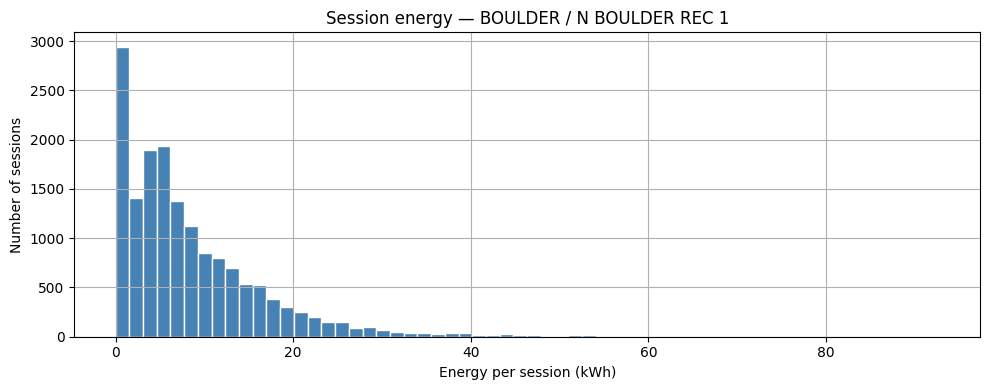

In [11]:
# Distribution of energy delivered per session
fig, ax = plt.subplots()
ax.hist(df_station['Energy__kWh_'], bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel('Energy per session (kWh)')
ax.set_ylabel('Number of sessions')
ax.set_title(f'Session energy — {TARGET_STATION}')
plt.tight_layout()
plt.show()

## Daily aggregation

For forecasting we aggregated sessions to a daily frequency. The target we picked is the **total energy delivered per day** at the chosen station.

Days with no recorded sessions stay in the index as zero-demand days, so the series is regularly spaced.

In [12]:
# Daily sum of energy at the target station
daily = (df_station
         .groupby('date')['Energy__kWh_']
         .sum()
         .rename('energy_kwh'))

# Reindex over the full daily range to make missing days explicit
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily = daily.reindex(full_idx).rename_axis('date')

print(f'Days in series: {len(daily)}')
print(f'Days with no sessions: {int(daily.isna().sum())}')

# Treat missing days as zero-demand days
daily = daily.fillna(0.0)
daily.head()

Days in series: 1927
Days with no sessions: 100


date
2018-08-22    29.816
2018-08-23     9.474
2018-08-24    29.668
2018-08-25     0.000
2018-08-26    47.488
Freq: D, Name: energy_kwh, dtype: float64

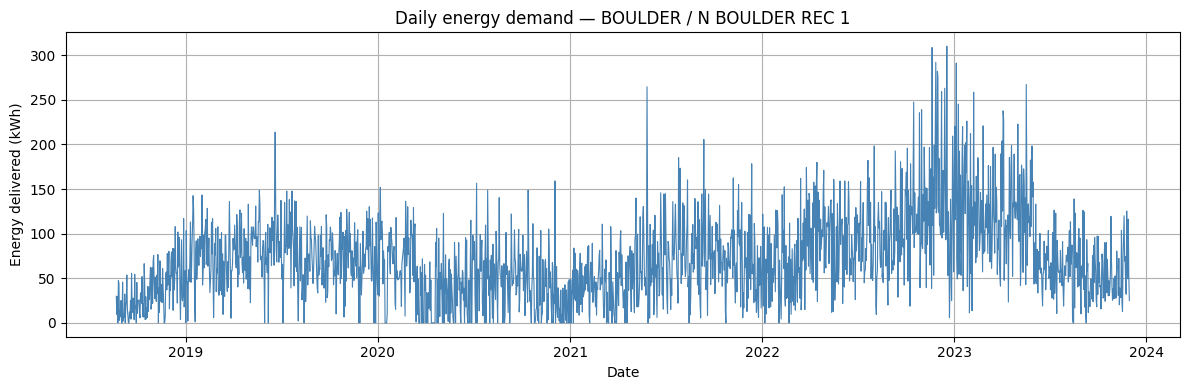

In [13]:
# Daily time series plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color='steelblue', lw=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Energy delivered (kWh)')
ax.set_title(f'Daily energy demand — {TARGET_STATION}')
plt.tight_layout()
plt.show()

## Seasonality exploration

We expected two seasonal patterns in EV charging demand:

- **Weekly** — commuter vs. weekend usage.
- **Annual** — weather and travel cycles.

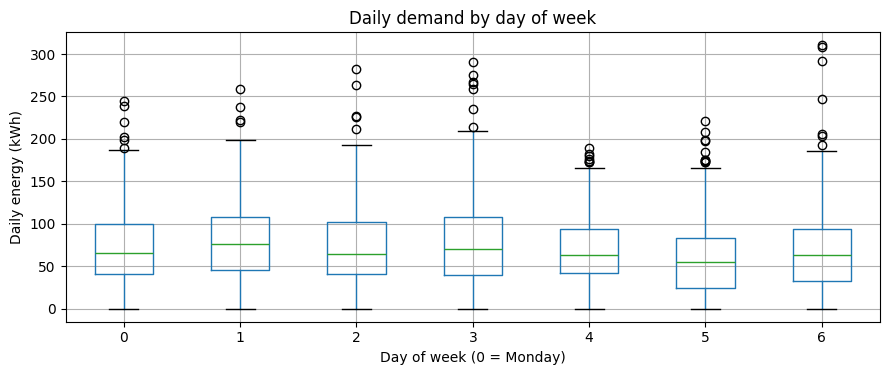

In [14]:
# Day-of-week and month features for the seasonality plots
daily_df = daily.to_frame()
daily_df['dow']   = daily_df.index.dayofweek    # 0 = Monday, 6 = Sunday
daily_df['month'] = daily_df.index.month

# Day-of-week boxplot
fig, ax = plt.subplots(figsize=(9, 4))
daily_df.boxplot(column='energy_kwh', by='dow', ax=ax)
ax.set_xlabel('Day of week (0 = Monday)')
ax.set_ylabel('Daily energy (kWh)')
ax.set_title('Daily demand by day of week')
plt.suptitle('')
plt.tight_layout()
plt.show()

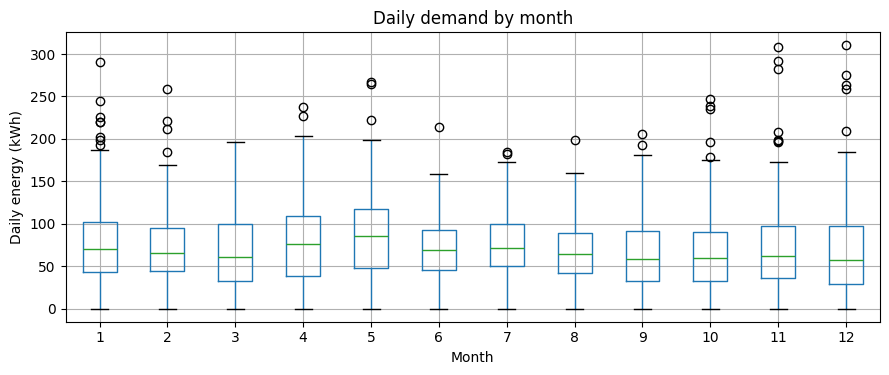

In [15]:
# Month-of-year boxplot
fig, ax = plt.subplots(figsize=(9, 4))
daily_df.boxplot(column='energy_kwh', by='month', ax=ax)
ax.set_xlabel('Month')
ax.set_ylabel('Daily energy (kWh)')
ax.set_title('Daily demand by month')
plt.suptitle('')
plt.tight_layout()
plt.show()

## STL decomposition (weekly seasonality)

A first look at trend, weekly seasonality, and residuals using STL with `period=7`. We left the annual decomposition for the SARIMA notebook (`04_sarima`).

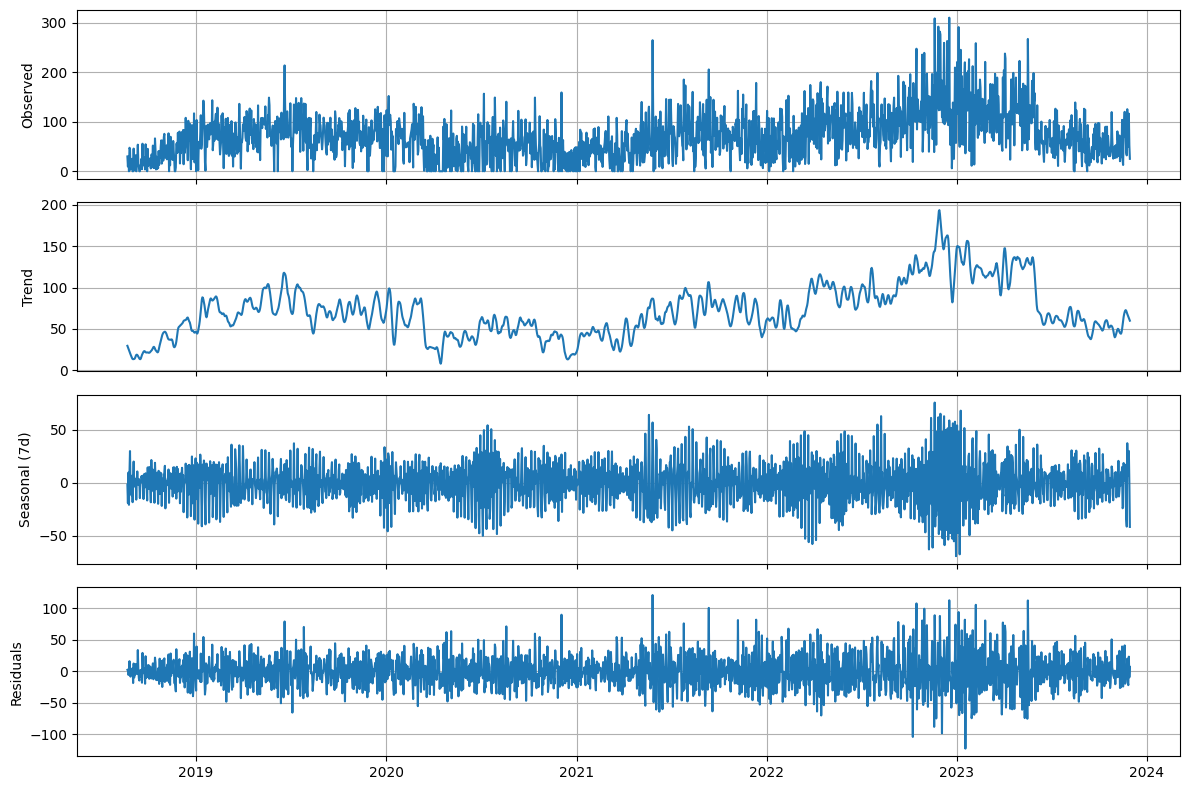

In [16]:
# STL decomposition with weekly period
stl = STL(daily, period=7).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(12, 8))

# Original series
ax1.plot(stl.observed); ax1.set_ylabel('Observed')
# Trend component
ax2.plot(stl.trend);    ax2.set_ylabel('Trend')
# Weekly seasonal component
ax3.plot(stl.seasonal); ax3.set_ylabel('Seasonal (7d)')
# Residuals
ax4.plot(stl.resid);    ax4.set_ylabel('Residuals')

plt.tight_layout()
plt.show()